## Workflow & Objective

This notebook demonstrates how to apply the Probabilistic Error Cancellation (PEC) technique using a Sparse Pauli–Lindblad noise model to mitigate hardware noise in a Variational Quantum Eigensolver (VQE).

We use a 4-site Transverse Field Ising Model (TFIM) and evaluate the ground state energy:

1. Ideal backend (shot noise only)

2. Realistic noisy backend (based on IBM hardware snapshots)

3. Mitigated results using Pauli-Lindblad-PER

The method follows the protocol from:

E. van den Berg, Z. K. Minev, A. Kandala, K. Temme $\textit{Probabilistic error cancellation with sparse Pauli–Lindblad model}\quad\quad$ arXiv:2201.09866 (2022)


The main idea:
Instead of correcting noise physically → invert its effect statistically through a learned noise model.


In [1]:
import sys; sys.path.append('../..')
import numpy as np
from src.plot_helpers import plot_topology

/home/users/ahmed/Desktop/AutomatedPERTools/.qiskit_venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## VQE Setup (Noise-Free Optimization)

We construct the TFIM Hamiltonian and a Hamiltonian Variational Ansatz (HVA) with one layer.
The VQE optimization is first executed without hardware noise, giving:

- approximate ground state
- optimal circuit parameters
- ideal expectation values of all Pauli terms

These will later serve as a reference for comparison.

In [12]:
from src.VQE_functions import optimize_energy, MFIM_Hamiltonian, build_hva_layers
from scipy.linalg import eigh
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, SparsePauliOp

topology = np.array([[0, 0], [1, 0], [1, 1], [0, 1]])

hx = 1
hz = 1
J = -1

Hamiltonian = MFIM_Hamiltonian(J=J, hx=hx, hz=hz, topology = topology)
pauli_list = [p.to_label() for p in Hamiltonian.paulis]
hva_layers, params = build_hva_layers(topology=topology, num_layers=1)

backend = AerSimulator()

num_layers = 1
initial_params = [1,1,1]
bounds = [(-np.pi, np.pi)] * 3*num_layers

opt_params, energy, HelperInfo = optimize_energy(initial_params=initial_params, Hamiltonian=Hamiltonian, topology=topology, num_layers=num_layers, backend=backend, mode="measurement",bounds = bounds)

values = {p: v for p, v in zip(params, opt_params)}
qc_bound = hva_layers.assign_parameters(values)
print(qc_bound.draw(fold=-1))

exact_energy = np.min(eigh(Hamiltonian.to_matrix(), eigvals_only=True))

psi = Statevector.from_instruction(qc_bound)
expectation_values = []
for pauli_str in pauli_list:
    op = SparsePauliOp.from_list([(pauli_str, 1.0)])
    expval = np.real(psi.expectation_value(op))
    expectation_values.append(expval)

print("Measured energy: ",energy)
print("Relative error: ", np.abs(energy - exact_energy) / np.abs(exact_energy) *100, "%")
print("initial parameters: ",initial_params)
print("optimale Parameter: ", opt_params)

Optimierung startet...
Optimierung fertig.
     ┌───┐┌─────────────┐┌───────────┐                                                                
q_0: ┤ H ├┤ Rz(-1.4437) ├┤ Rx(1.371) ├──■─────────────────■────■──────────────────────────────■───────
     ├───┤├─────────────┤├───────────┤┌─┴─┐┌───────────┐┌─┴─┐  │                              │       
q_1: ┤ H ├┤ Rz(-1.4437) ├┤ Rx(1.371) ├┤ X ├┤ Rz(1.196) ├┤ X ├──┼────────■─────────────────────┼────■──
     ├───┤├─────────────┤├───────────┤└───┘└───────────┘└───┘  │      ┌─┴─┐    ┌───────────┐  │  ┌─┴─┐
q_2: ┤ H ├┤ Rz(-1.4437) ├┤ Rx(1.371) ├──■─────────────────■────┼──────┤ X ├────┤ Rz(1.196) ├──┼──┤ X ├
     ├───┤├─────────────┤├───────────┤┌─┴─┐┌───────────┐┌─┴─┐┌─┴─┐┌───┴───┴───┐└───────────┘┌─┴─┐└───┘
q_3: ┤ H ├┤ Rz(-1.4437) ├┤ Rx(1.371) ├┤ X ├┤ Rz(1.196) ├┤ X ├┤ X ├┤ Rz(1.196) ├─────────────┤ X ├─────
     └───┘└─────────────┘└───────────┘└───┘└───────────┘└───┘└───┘└───────────┘             └───┘     
Measured energy:  -8.616
Relat

Here we choose a backend. A Qiskit backend refers to the specific quantum computing resource, either a simulator or a real quantum device, that one can use to run quantum circuits. Each backend has its own characteristics, such as the number of qubits and operational status, which can be accessed through the Qiskit framework. The backends from qiskit_ibm_runtime.fake_provider like FakeWashingtonV2 are snapshots of physically realized QPUs. Therefore the noisemodels associated are realistic.

In [ ]:
from qiskit.transpiler import CouplingMap
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_ibm_runtime.fake_provider import FakeWashingtonV2
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

# FakeBackend mit Noise laden
fake_backend = FakeWashingtonV2()
noise_model = NoiseModel.from_backend(fake_backend)
backend_noisy = AerSimulator(noise_model=noise_model)


In [ ]:

phys_qubits = [0,1,2,3]

# FakeBackend ohne Noise laden
coupling = CouplingMap(couplinglist=[(0, 1), (1, 2), (2, 3)])
backend = GenericBackendV2(num_qubits=4, coupling_map=coupling)
#backend = AerSimulator() Alternative

## Noisy Backend Simulation

Quantum hardware introduces imperfections:

- Two-qubit gate errors

- Crosstalk

- Relaxation & dephasing

- Readout errors

We emulate this using a Fake IBM hardware backend from Qiskit, which comes with:

✔ realistic noise model
✔ real device connectivity constraints

Running the previously optimized circuit now results in:

significantly larger relative error in the energy estimate

This highlights why error mitigation strategies are required for NISQ-era circuits.

In [4]:
from src.VQE_functions import compute_exp_value

energy_noisy = compute_exp_value(qc_bound,Hamiltonian,fake_backend,phys_qubits=phys_qubits)

print("Measured energy: ",energy_noisy)
print("Relative error: ", np.abs(energy_noisy - exact_energy) / np.abs(exact_energy) *100, "%")

Measured energy:  (-7.44140625+0j)
Relative error:  14.130543795525341 %


# Run Experiment

In [5]:
from pauli_lindblad_per.tomography.experiment import SparsePauliTomographyExperiment as tomography
from qiskit.primitives import BackendSamplerV2


shots = 1024
sampler = BackendSamplerV2(backend = fake_backend, options={"default_shots":shots})

experiment = tomography(
    circuits = [qc_bound], #list of circuits from which to get the layers requiring tomography
    backend = fake_backend, #quantum backend
    phys_qubits=phys_qubits # physical Qubits on which all operations will be performed
    )

experiment.generate(
    samples = 50, #Number of samples to take from the fidelity pair measurements
    single_samples = 100, #samples to take from the pair-breaking measurements
    depths = [2,4,8], #values of 2n to make the pair measurements. Numbers must be even and non-zero
    shots = shots
    )

def executor(circuits):
    res = sampler.run(circuits).result()
    list_counts_dict = [r.data.meas.get_counts() for r in res]
    return list_counts_dict

#run the experiment
experiment.run(executor, auto_save=False)
noisedataframe = experiment.analyze()

=== Tomography ===
Circuits:       3900
Backend runs:  3993600
Details:
  N_layers        : 2
  num_meas_bases  : 9
  depth_count     : 3
  samples         : 50
  single_samples  : 100
  sum_single_bases: 12


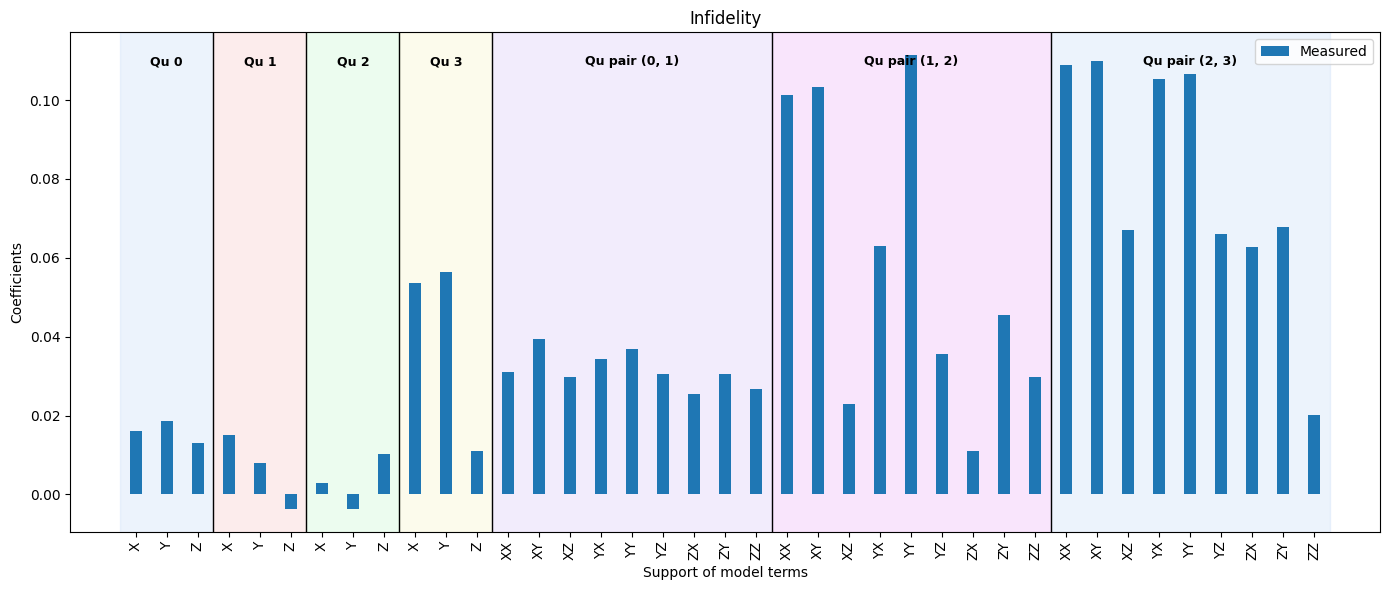

In [6]:
layer1 = experiment.analysis.get_layer_data(layer=0)
layer1.plot_infidelitites()

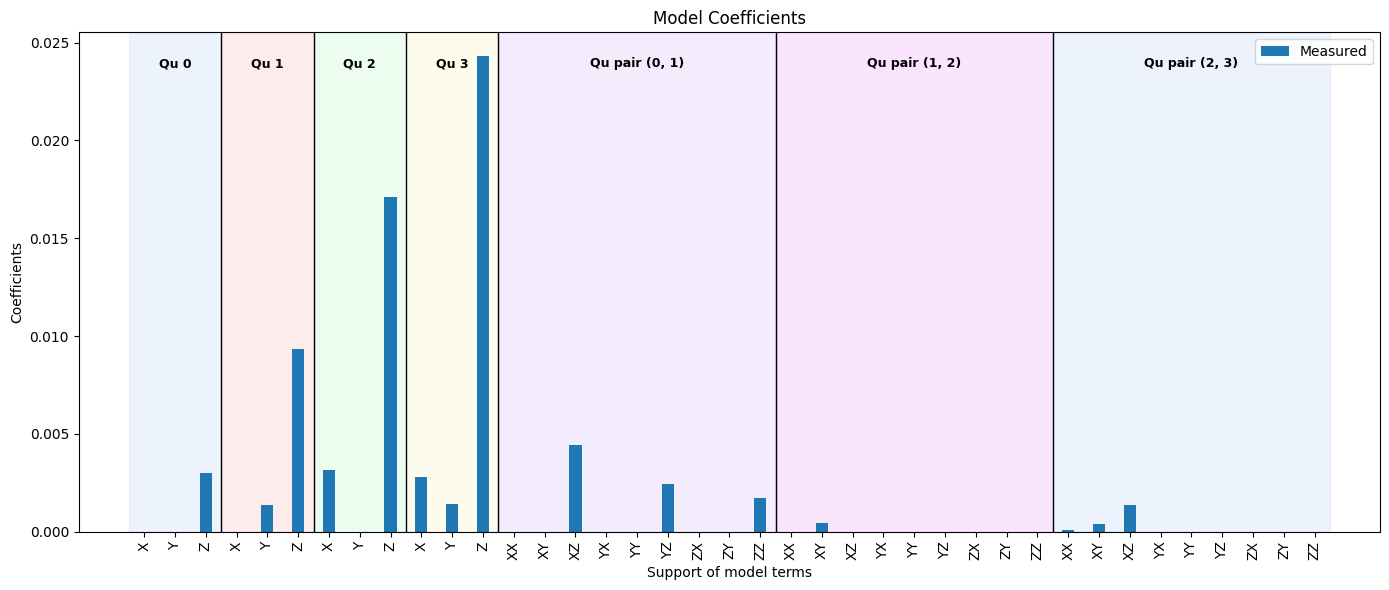

In [11]:
layer1.plot_coeffs()

# Run PER

In [8]:
# 2. PER-Experiment Setup
perexp = experiment.create_per_experiment([qc_bound])

perexp.generate(
    expectations=pauli_list,
    samples=1000, 
    noise_strengths=[0, 1, 2],
    shots = shots
)
perexp.run(executor)


=== PER ===
Circuits:       6000
Backend runs:  6144000
Details:
  num_meas_bases_per : 2
  num_noise_strengths: 3
  samples            : 1000


Aus SV-Simulation:  0.9392369663747137


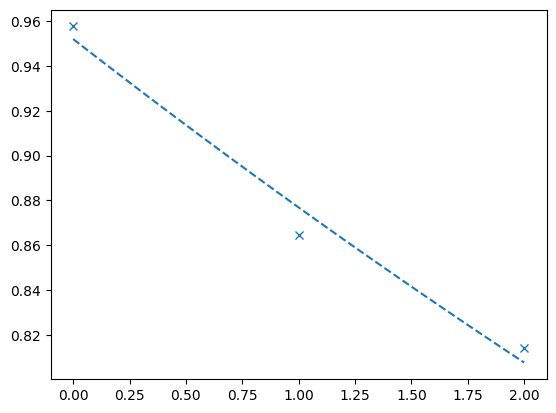

In [9]:
# 4. Analysieren
per_results = perexp.analyze()
result_1 = per_results[0].get_result(pauli_list[2]).plot()
print("Aus SV-Simulation: ",expectation_values[1])

In [10]:
# Compare absolute vs relative errors
for k in range(len(pauli_list)):
    exact = expectation_values[k]
    calc = per_results[0].get_result(pauli_list[k]).get_expectations()[0]
    abs_error = abs(exact - calc)
    rel_error = abs_error / abs(exact) if exact != 0 else float('inf')
    
    print(f"{pauli_list[k]}: Exact={exact:.4f}, Calc={calc:.4f}")
    print(f"  Absolute error: {abs_error:.6f}")
    print(f"  Relative error: {rel_error*100:.2f}%")
    print()

IIZZ: Exact=0.9392, Calc=0.9246
  Absolute error: 0.014638
  Relative error: 1.56%

ZIIZ: Exact=0.9392, Calc=0.9222
  Absolute error: 0.017055
  Relative error: 1.82%

IZZI: Exact=0.9392, Calc=0.9577
  Absolute error: 0.018421
  Relative error: 1.96%

ZZII: Exact=0.9392, Calc=0.9639
  Absolute error: 0.024661
  Relative error: 2.63%

IIIX: Exact=-0.2265, Calc=-0.2145
  Absolute error: 0.012061
  Relative error: 5.32%

IIIZ: Exact=-0.9691, Calc=-0.9565
  Absolute error: 0.012636
  Relative error: 1.30%

IIXI: Exact=-0.2265, Calc=-0.1962
  Absolute error: 0.030380
  Relative error: 13.41%

IIZI: Exact=-0.9691, Calc=-0.9794
  Absolute error: 0.010264
  Relative error: 1.06%

IXII: Exact=-0.2265, Calc=-0.2219
  Absolute error: 0.004594
  Relative error: 2.03%

IZII: Exact=-0.9691, Calc=-0.9632
  Absolute error: 0.005933
  Relative error: 0.61%

XIII: Exact=-0.2265, Calc=-0.2118
  Absolute error: 0.014752
  Relative error: 6.51%

ZIII: Exact=-0.9691, Calc=-1.0164
  Absolute error: 0.047245
